# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [99]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Saul Eduardo Diaz Fonseca"            # Tu nombre completo
MATRICULA = "81345"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutricion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Saul Eduardo Diaz Fonseca
Matrícula: 81345
Dataset asignado: desnutricion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [100]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\sauld\Universidad\BigData\U1_1_probabilidad_estadistica\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [102]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [103]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [104]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [105]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [106]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [107]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Respuesta:
Únicamente la variable "code" tiene nulos, lo que significa que son algunos paises que no tienen su "identificador" y puede llegar a afectar en consultas.
También se tiene una media muy alta en desnutrición, más de millones de personas que se encuentran en esa situación.
En cuanto al tiempo no es tanto como para tener estos números ( 2000 al 2024).

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [108]:
# Pregunta 1
# Tu codigo aqui
df_paises = df[df["code"].notnull()]
print("Cantidad paises:",df_paises["entity"].nunique())
print("---")

paises_unicos = df_paises.groupby("entity")["valor"].max().sort_values(ascending=False)

print(paises_unicos.head(10))
print("-----")

print(paises_unicos.tail(10))


Cantidad paises: 140
---
entity
World                           825200000.0
India                           247000000.0
China                           127300000.0
Nigeria                          45400000.0
Indonesia                        42400000.0
Pakistan                         40900000.0
Democratic Republic of Congo     40700000.0
Ethiopia                         32100000.0
Bangladesh                       27800000.0
Kenya                            20400000.0
Name: valor, dtype: float64
-----
entity
New Caledonia                       100000.0
Mauritius                           100000.0
Sao Tome and Principe               100000.0
Samoa                               100000.0
Saint Vincent and the Grenadines    100000.0
North Macedonia                     100000.0
Suriname                            100000.0
Seychelles                          100000.0
Vanuatu                             100000.0
Uruguay                             100000.0
Name: valor, dtype: float64


**Interpretación:**

Existen un total de 173 paises reales ( con el atributo code), donde tienen una gran diferencia entre ambos extremos, donde los paises mas altos como "world,Asia o Africa " tienen cientos de millones de valores, los paises mas bajos como "Guyana, Polynesia o Sao Tome and principe" tienen tan solo cientos de miles.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [109]:
# Pregunta 2
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"]
samoa = df_paises[df_paises["entity"] == "Samoa"]
print("Mexico:")
print(mexico.head(10))
print("---")
print("Samoa:")
print(samoa.head(10))

Mexico:
      entity code  year      valor
1964  Mexico  MEX  2001  2800000.0
1965  Mexico  MEX  2002  3300000.0
1966  Mexico  MEX  2003  3900000.0
1967  Mexico  MEX  2004  4300000.0
1968  Mexico  MEX  2005  4200000.0
1969  Mexico  MEX  2006  4000000.0
1970  Mexico  MEX  2007  4000000.0
1971  Mexico  MEX  2008  4400000.0
1972  Mexico  MEX  2009  4600000.0
1973  Mexico  MEX  2010  4600000.0
---
Samoa:
     entity code  year     valor
2603  Samoa  WSM  2001  100000.0
2604  Samoa  WSM  2002  100000.0
2605  Samoa  WSM  2003  100000.0
2606  Samoa  WSM  2004  100000.0
2607  Samoa  WSM  2005  100000.0
2608  Samoa  WSM  2006  100000.0
2609  Samoa  WSM  2007  100000.0
2610  Samoa  WSM  2008  100000.0
2611  Samoa  WSM  2009  100000.0
2612  Samoa  WSM  2010  100000.0


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [110]:
# Pregunta 3
# Tu codigo aqui
paises_seleccionados = ["Mexico", "Asia (FAO)", "Uruguay", "Southern Asia (FAO)", "Low Income Food Deficit Countries (FAO)"]
df_5 = df[df["entity"].isin(paises_seleccionados)]

df_ordenado = df_5.sort_values(by="valor", ascending=False)

print("Comparación de los 5 países :")
print(df_ordenado[["entity", "valor"]])

valor_mas_alto = df_ordenado["valor"].iloc[0]
valor_mas_bajo = df_ordenado["valor"].iloc[-1]
diferencia = valor_mas_alto - valor_mas_bajo
print("La diferencia entre el país con el valor más alto y el más bajo es:", diferencia)





Comparación de los 5 países :
          entity        valor
170   Asia (FAO)  572600000.0
172   Asia (FAO)  570100000.0
171   Asia (FAO)  567000000.0
173   Asia (FAO)  552200000.0
169   Asia (FAO)  551500000.0
...          ...          ...
1964      Mexico    2800000.0
3319     Uruguay     100000.0
3320     Uruguay     100000.0
3321     Uruguay     100000.0
3322     Uruguay     100000.0

[102 rows x 2 columns]
La diferencia entre el país con el valor más alto y el más bajo es: 572500000.0


**Interpretación:**

Los paises extremos de mi eleccion fueron Asia y Uruguay, donde tienen una diferencia de cientos de millones, lo cual puede deberse principalmente a la diferencia poblacional, pero tambien pueden afectar valores externos como a la economia y contexto social de cada pais.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [111]:
# Pregunta 4
# Tu codigo aqui
latam = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

df_reciente = df_paises.sort_values("year").drop_duplicates("entity", keep="last")

promedio_latam = df_reciente[df_reciente["entity"].isin(latam)]["valor"].mean()
promedio_asia = df_reciente[df_reciente["entity"].isin(asia)]["valor"].mean()

print(f"Promedio Latam: {promedio_latam}")
print(f"Promedio Asia: {promedio_asia}")


Promedio Latam: 2333333.3333333335
Promedio Asia: 21900000.0


**Interpretación:**

El promedio de asia es muy superior al de latinoamerica, esto puede ser debido a que los paises de asia incluyen a asia y japon, los cuales tienen una poblacion considerablemente mas grande, por lo cual hay mas escases de alimentos.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [112]:
# Pregunta 5
# Tu codigo aqui
df_ordenado_valor = mexico.sort_values("valor")

minimo = df_ordenado_valor.iloc[0] # min
maximo = df_ordenado_valor.iloc[-1] #max

print(f"AÑO CON MENOS DESNUTRICIÓN: {minimo['year']} (Valor: {minimo['valor']})")
print(f"AÑO CON MÁS DESNUTRICIÓN: {maximo['year']} (Valor: {maximo['valor']})")

print("\n--- Histórico de México (Ordenado por Año) ---")
print(mexico.sort_values("year")[["year", "valor"]])


AÑO CON MENOS DESNUTRICIÓN: 2001 (Valor: 2800000.0)
AÑO CON MÁS DESNUTRICIÓN: 2017 (Valor: 4600000.0)

--- Histórico de México (Ordenado por Año) ---
      year      valor
1964  2001  2800000.0
1965  2002  3300000.0
1966  2003  3900000.0
1967  2004  4300000.0
1968  2005  4200000.0
1969  2006  4000000.0
1970  2007  4000000.0
1971  2008  4400000.0
1972  2009  4600000.0
1973  2010  4600000.0
1974  2011  4400000.0
1975  2012  4500000.0
1976  2013  4400000.0
1977  2014  4500000.0
1978  2015  4400000.0
1979  2016  4500000.0
1980  2017  4600000.0
1981  2018  4500000.0
1982  2019  4300000.0
1983  2020  3900000.0
1984  2021  3800000.0
1985  2022  3600000.0
1986  2023  3500000.0


**Interpretación:**

La diferencia entre el año mas bajo ( 2001 ) con la del mas algo ( 2017 ) es abismas, de casi el doble de su valor, es un incremento muy rapido, pero despues del pico de 2017 se observa que en cada año se iba disminuyendo esta cantidad, llengaod al punto más bajo de los ultimos años.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [113]:
# Pregunta 6
# Tu codigo aqui
df_mexico = mexico.sort_values("year")

valor_inicial = df_mexico.iloc[0]["valor"]
valor_final = df_mexico.iloc[-1]["valor"]

cambio_porcentual = ((valor_final - valor_inicial) / valor_inicial) * 100

print(f"El cambio porcentual es: {cambio_porcentual:.2f}%")


El cambio porcentual es: 25.00%


**Interpretación:**

Presenta un incremento del 25%, paso de 2 millones en 2001  a 3.5 millones en 2023. Este incremento puede ser debido a varios factores, crecimiento poblacional o que en esos haños haya pasado por crisis economicas las cuales hacen que sea mas complicado poder regresar ese valor a como era en 2001, aunque sigue siendo una gran mejora de los años pasados ( 2017 pico mas alto )

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [114]:
# Pregunta 7
# Tu codigo aqui

df_reciente = df_paises.sort_values(by="year", ascending=False).drop_duplicates(subset=["entity"])
valores_limpios = df_reciente["valor"].dropna()
media = np.mean(valores_limpios)
mediana = np.median(valores_limpios)
desviacion = np.std(valores_limpios)

print(f"Media: {media:,.2f}")
print(f"Mediana: {mediana:,.2f}")
print(f"Desviación Estándar: {desviacion:,.2f}")


Media: 9,781,428.57
Mediana: 900,000.00
Desviación Estándar: 58,539,520.94


**Interpretación:**

La media y la mediana tienen valores muy diferentes, esto de debe a que al incluir paises grandes como los asiaticos, estos pueden tener valores muy extremistas que afectan al valor real, por eso la mediana es un valor mas confiable.
La cual nos dice que el 50% de los paises  menos de 900,000 personas en desnutricion, y que la otra mitad tiene mas.
En cuanto a la desviacion nos indica que los valores son muy dispersos entre si, por eso la mediana es un mejor valor para comprobar en este caso.


### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

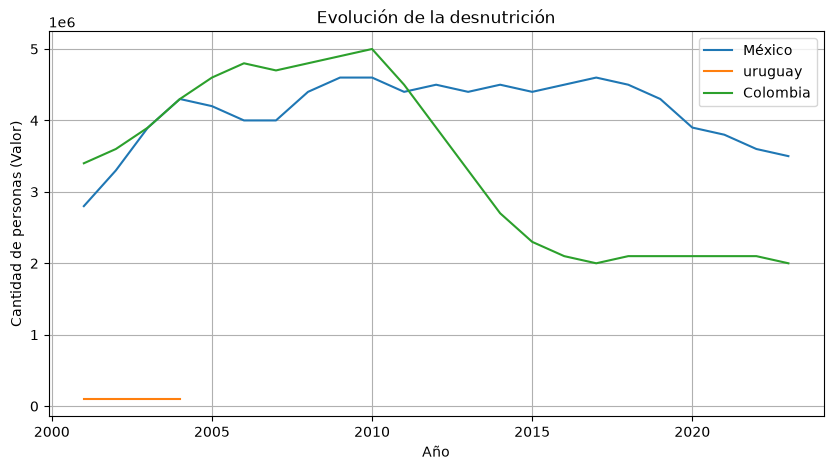

In [115]:
# Pregunta 8
# Tu codigo aqui

df_mexico = df[df["entity"] == "Mexico"].sort_values("year")
df_uruguay = df[df["entity"] == "Uruguay"].sort_values("year")
df_colombia = df[df["entity"] == "Colombia"].sort_values("year") # Agregamos un tercero como pedía tu instrucción

plt.figure(figsize=(10,5))

plt.plot(
    df_mexico["year"],
    df_mexico["valor"],
    label="México"
)
plt.plot(
    df_uruguay["year"],
    df_uruguay["valor"],
    label="uruguay"
)
plt.plot(
    df_colombia["year"],
    df_colombia["valor"],
    label="Colombia"
)

plt.title("Evolución de la desnutrición")
plt.xlabel("Año")
plt.ylabel("Cantidad de personas (Valor)")
plt.grid(True)
plt.legend()
plt.show()

**Interpretación:**

Con la grafica se puede que mientras colombia muestra una reduccion profunda en cinco años, mexico a tenido mas problemas para bajar ese valor, mientras que uruguay al no tener tantos registros se mantuvo constante.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

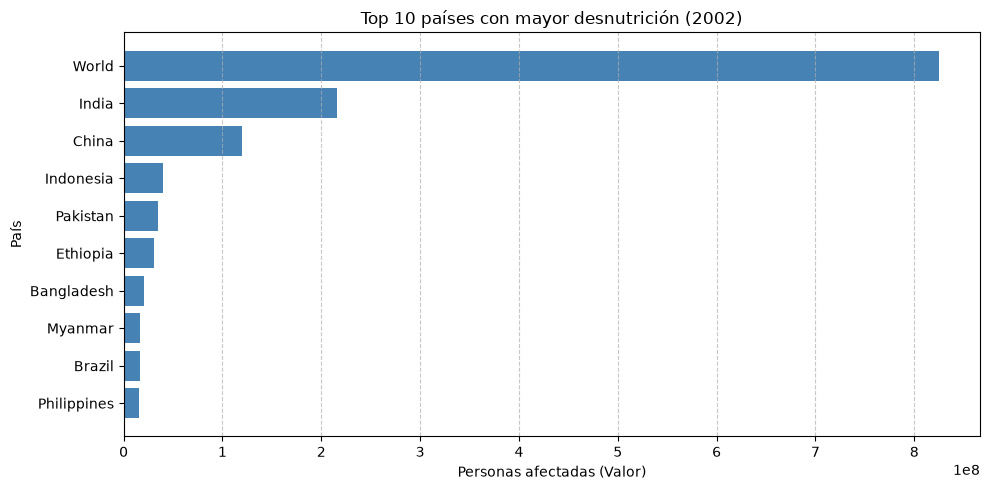

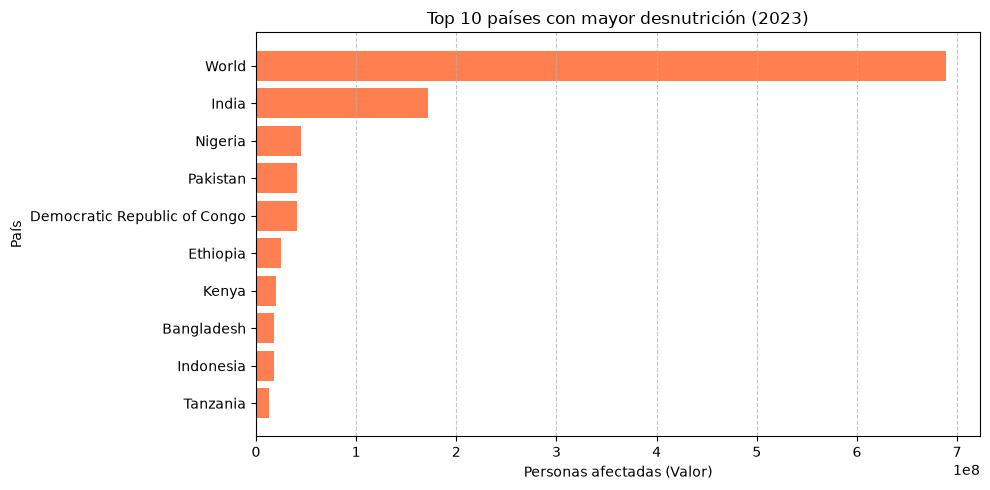

In [116]:
# Pregunta 9
# Tu codigo aqui

anio_nacimiento = 2002
anio_reciente = 2023
top_2002 = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)
top_2023 = (
    df_paises[df_paises['year'] == anio_reciente]
    .sort_values('valor', ascending=False)
    .head(10)
)

# 2002
plt.figure(figsize=(10, 5))
plt.barh(top_2002['entity'], top_2002['valor'], color='steelblue')
plt.xlabel("Personas afectadas (Valor)")
plt.ylabel("País")
plt.title(f"Top 10 países con mayor desnutrición ({anio_nacimiento})")
plt.gca().invert_yaxis()  # Para que el valor más alto quede arriba
plt.grid(axis='x', linestyle='--', alpha=0.7) # Una cuadrícula suave para leer mejor los valores
plt.tight_layout()
plt.show()

# 2023
plt.figure(figsize=(10, 5))
plt.barh(top_2023['entity'], top_2023['valor'], color='coral')
plt.xlabel("Personas afectadas (Valor)")
plt.ylabel("País")
plt.title(f"Top 10 países con mayor desnutrición ({anio_reciente})")
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Interpretación:**

Países como China y Brasil, que figuraban fuertemente en el Top 10 en 2002, lograron salir por completo de la lista para 2023, lo que indica un progreso masivo en su seguridad alimentaria. Sin embargo, esos lugares fueron ocupados por naciones africanas que irrumpieron abruptamente en los puestos más altos, como Nigeria, República Democrática del Congo, Kenia y Tanzania. 

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Conclusion:
Al analizar los datos, descubrí que la crisis de desnutrición cambió de zonas: Brasil y China mejoraron mucho desde 2002, pero varios países africanos empeoraron y entraron al Top 10, mientras que India siempre se mantuvo en el primer lugar.

La mayor limitación es que los datos usan números totales y no porcentajes. Esto engaña a la vista, porque los países con mucha población siempre se verán peor, ocultando crisis muy graves en países pequeños. Además, los datos venían un poco sucios (mezclaban continentes con países) y tenían años vacíos.

Si tuviera más tiempo, convertiría los valores a porcentajes para hacer comparaciones más justas, limpiaría mejor la lista de países para borrar regiones como "World", y compararía estos datos con la economía de cada país para entender mejor el problema.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
